# Regression Discontinuity — Close Senate Elections & Incumbency Advantage

Working through this step by step.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:


df = pd.read_csv("../data/raw/senate.csv")

print(df.shape)
df.head()


(1390, 8)


,state,year,vote,margin,class,termshouse,termssenate,population
0,1,1914,36.097572,-7.688561,3,3.0,6.0,1233000
1,1,1916,45.468746,-3.923708,1,0.0,4.0,1294000
2,1,1922,45.598213,-6.868660,1,0.0,7.0,1431000
3,1,1926,48.476063,-27.668056,3,0.0,3.0,1531000
4,1,1928,51.746868,-8.256968,1,0.0,1.0,1577000


In [3]:
df = df.rename(columns={
    "state": "state_id",
    "year": "election_year",
    "vote": "dem_vote_share_next_election",
    "margin": "dem_margin_over_50pct",
    "class": "senate_class",
    "termshouse": "terms_served_house",
    "termssenate": "terms_served_senate",
    "population": "state_population",
})

df.head()


,state_id,election_year,dem_vote_share_next_election,dem_margin_over_50pct,senate_class,terms_served_house,terms_served_senate,state_population
0,1,1914,36.097572,-7.688561,3,3.0,6.0,1233000
1,1,1916,45.468746,-3.923708,1,0.0,4.0,1294000
2,1,1922,45.598213,-6.868660,1,0.0,7.0,1431000
3,1,1926,48.476063,-27.668056,3,0.0,3.0,1531000
4,1,1928,51.746868,-8.256968,1,0.0,1.0,1577000


## validate

In [4]:
df.isnull().sum()

state_id                          0
election_year                     0
dem_vote_share_next_election     93
dem_margin_over_50pct             0
senate_class                      0
terms_served_house              282
terms_served_senate             282
state_population                  0
dtype: int64

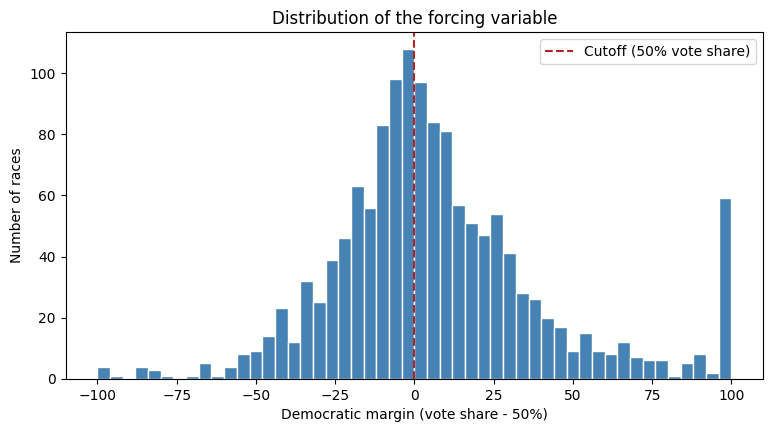

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))

bins = np.arange(-100, 101, 4)
ax.hist(df["dem_margin_over_50pct"], bins=bins, color="steelblue", edgecolor="white")
ax.axvline(0, color="firebrick", linestyle="--", linewidth=1.5, label="Cutoff (50% vote share)")
ax.set_xlabel("Democratic margin (vote share - 50%)")
ax.set_ylabel("Number of races")
ax.set_title("Distribution of the forcing variable")
ax.legend()
plt.show()


In [6]:
from scipy.stats import binomtest

window = 5  # margin points on each side of the cutoff

just_below = df[(df["dem_margin_over_50pct"] >= -window) & (df["dem_margin_over_50pct"] < 0)]
just_above = df[(df["dem_margin_over_50pct"] >= 0) & (df["dem_margin_over_50pct"] < window)]

n_below = len(just_below)
n_above = len(just_above)
n_total = n_below + n_above

result = binomtest(n_above, n_total, p=0.5)

print(f"Races in [-{window}, 0)  : {n_below}")
print(f"Races in [0, {window})   : {n_above}")
print(f"Total in window         : {n_total}")
print(f"p-value                 : {result.pvalue:.3f}")


Races in [-5, 0)  : 132
Races in [0, 5)   : 125
Total in window         : 257
p-value                 : 0.708


In [7]:
rdd = df.dropna(subset=["dem_vote_share_next_election", "dem_margin_over_50pct"])
print(f"Dropped {len(df) - len(rdd)} races with no next-election outcome")

BIN_WIDTH = 5
bin_edges = np.arange(-100, 101, BIN_WIDTH)
rdd = rdd.assign(margin_bin=pd.cut(rdd["dem_margin_over_50pct"], bin_edges, include_lowest=True))

binned = rdd.groupby("margin_bin", observed=True).agg(
    margin_mid=("dem_margin_over_50pct", "mean"),
    vote_mean=("dem_vote_share_next_election", "mean"),
    n=("dem_vote_share_next_election", "size"),
).dropna()

binned.head()


Dropped 93 races with no next-election outcome


,margin_mid,vote_mean,n
margin_bin,,,
"(-100.001, -95.0]",-99.679609,33.928423,3
"(-95.0, -90.0]",-94.542435,0.000000,1
"(-90.0, -85.0]",-86.618168,40.624009,2
"(-85.0, -80.0]",-82.646034,46.862368,4
"(-80.0, -75.0]",-79.322525,43.499397,1


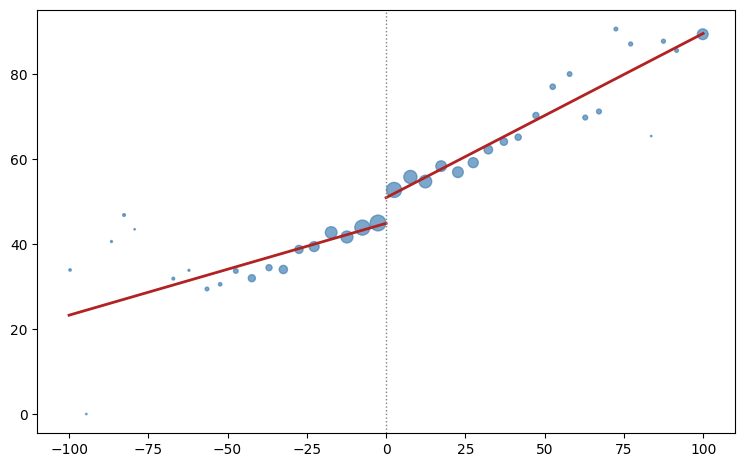

In [8]:
left = rdd[rdd["dem_margin_over_50pct"] < 0]
right = rdd[rdd["dem_margin_over_50pct"] >= 0]

left_coefs = np.polyfit(left["dem_margin_over_50pct"], left["dem_vote_share_next_election"], deg=1)
right_coefs = np.polyfit(right["dem_margin_over_50pct"], right["dem_vote_share_next_election"], deg=1)

grid_left = np.linspace(-100, 0, 100)
grid_right = np.linspace(0, 100, 100)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(binned["margin_mid"], binned["vote_mean"], s=binned["n"], color="steelblue", alpha=0.7, label="Binned average")
ax.plot(grid_left, np.polyval(left_coefs, grid_left), color="firebrick", linewidth=2)
ax.plot(grid_right, np.polyval(right_coefs, grid_right), color="firebrick", linewidth=2)
ax.axvline(0, color="grey", linestyle=":", linewidth=1)


## RD estimate

Restrict to races within a bandwidth of the cutoff, then fit one regression with a treatment indicator (`won`) and an interaction term, so the slope is allowed to differ on each side, matching the two separate lines from the plot. The coefficient on `won` is the jump at the cutoff — our RD estimate.

In [9]:
import statsmodels.formula.api as smf

BANDWIDTH = 20  # margin points on each side of the cutoff

local = rdd[rdd["dem_margin_over_50pct"].abs() <= BANDWIDTH].copy()
local["won"] = (local["dem_margin_over_50pct"] >= 0).astype(int)
local["margin_x_won"] = local["dem_margin_over_50pct"] * local["won"]

model = smf.ols(
    "dem_vote_share_next_election ~ dem_margin_over_50pct + won + margin_x_won",
    data=local,
).fit()

print(f"Races within {BANDWIDTH} points of the cutoff: {len(local)}")
model.summary()


Races within 20 points of the cutoff: 735


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     dem_vote_share_next_election   R-squared:                       0.266
Model:                                      OLS   Adj. R-squared:                  0.263
Method:                           Least Squares   F-statistic:                     88.50
Date:                          Fri, 31 Jul 2026   Prob (F-statistic):           7.34e-49
Time:                                  13:45:20   Log-Likelihood:                -2710.4
No. Observations:                           735   AIC:                             5429.
Df Residuals:                               731   BIC:                             5447.
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                45.3865      0.906     50.104      0.000      43.608      47.165
dem_margin_over_50pct     0.2053      0.089      2.309      0.021       0.031       0.380
won                       7.0283      1.322      5.315      0.000       4.432       9.625
margin_x_won              0.0883      0.129      0.685      0.494      -0.165       0.342
==============================================================================
Omnibus:                       70.998   Durbin-Watson:                   1.742
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              225.314
Skew:                          -0.440   Prob(JB):                     1.19e-49
Kurtosis:                       5.566   Cond. No.                         48.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Bandwidth sensitivity

The `BANDWIDTH = 20` choice above was arbitrary. Refit the same regression across a range of bandwidths and check whether the estimate holds up.

In [10]:
bandwidths = [5, 10, 15, 20, 25, 30, 40, 50]

rows = []
for bw in bandwidths:
    local_bw = rdd[rdd["dem_margin_over_50pct"].abs() <= bw].copy()
    local_bw["won"] = (local_bw["dem_margin_over_50pct"] >= 0).astype(int)
    local_bw["margin_x_won"] = local_bw["dem_margin_over_50pct"] * local_bw["won"]

    m = smf.ols(
        "dem_vote_share_next_election ~ dem_margin_over_50pct + won + margin_x_won",
        data=local_bw,
    ).fit()
    ci = m.conf_int().loc["won"]

    rows.append({
        "bandwidth": bw,
        "n": len(local_bw),
        "estimate": m.params["won"],
        "ci_lower": ci[0],
        "ci_upper": ci[1],
    })

sensitivity = pd.DataFrame(rows)
sensitivity


,bandwidth,n,estimate,ci_lower,ci_upper
0,5,245,9.825994,5.063219,14.588768
1,10,451,6.898794,3.457787,10.339802
2,15,607,6.963837,4.010213,9.917461
3,20,735,7.028278,4.432029,9.624528
4,25,845,7.383816,5.003964,9.763668
5,30,931,7.181910,4.863775,9.500046
6,40,1051,6.121469,3.917893,8.325046
7,50,1127,5.729203,3.637284,7.821123


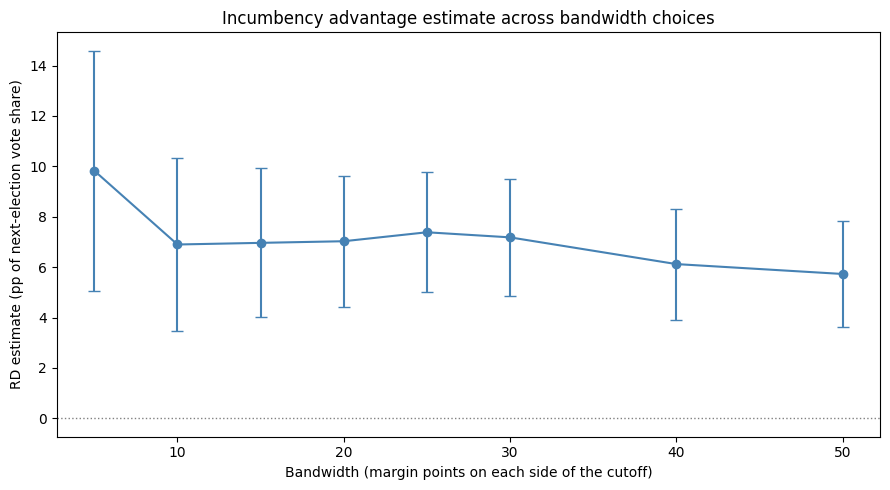

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    sensitivity["bandwidth"], sensitivity["estimate"],
    yerr=[sensitivity["estimate"] - sensitivity["ci_lower"], sensitivity["ci_upper"] - sensitivity["estimate"]],
    fmt="o-", color="steelblue", ecolor="steelblue", capsize=4,
)
ax.axhline(0, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("Bandwidth (margin points on each side of the cutoff)")
ax.set_ylabel("RD estimate (pp of next-election vote share)")
ax.set_title("Incumbency advantage estimate across bandwidth choices")
plt.tight_layout()
plt.show()


## Covariate balance check

If close elections are effectively randomized, a **predetermined** covariate — something the election outcome can't have caused — should show no jump at the cutoff. `state_population` is unrelated to who wins a Senate race, so it's a natural placebo test: same regression as before, just with `state_population` as the outcome instead of `dem_vote_share_next_election`. If `won` came out significant here, it would mean winning and losing sides differ systematically even before the election — a sign the design is broken.

In [12]:
balance = df.dropna(subset=["state_population", "dem_margin_over_50pct"]).copy()
balance = balance[balance["dem_margin_over_50pct"].abs() <= BANDWIDTH]
balance["won"] = (balance["dem_margin_over_50pct"] >= 0).astype(int)
balance["margin_x_won"] = balance["dem_margin_over_50pct"] * balance["won"]

balance_model = smf.ols(
    "state_population ~ dem_margin_over_50pct + won + margin_x_won",
    data=balance,
).fit()

balance_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       state_population   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.4628
Date:                Fri, 31 Jul 2026   Prob (F-statistic):              0.708
Time:                        13:45:20   Log-Likelihood:                -13103.
No. Observations:                 778   AIC:                         2.621e+04
Df Residuals:                     774   BIC:                         2.623e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              4.536e+06   4.59e+05      9.878      0.000    3.63e+06    5.44e+06
dem_margin_over_50pct  4.451e+04   4.44e+04      1.003      0.316   -4.26e+04    1.32e+05
won                    -4.33e+05   6.64e+05     -0.652      0.514   -1.74e+06     8.7e+05
margin_x_won          -2.256e+04   6.44e+04     -0.350      0.726   -1.49e+05    1.04e+05
==============================================================================
Omnibus:                      480.542   Durbin-Watson:                   0.168
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4435.430
Skew:                           2.729   Prob(JB):                         0.00
Kurtosis:                      13.346   Cond. No.                         49.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""